# Pattern Analysis: Replica & SLO (Response Time)

Pattern analysis replica count and SLO (response time)
- **Q-Learning (QL)**
- **Q-Learning Fuzzy (QF)**
- **HPA (Baseline)**


## 1. Setup & Konfigurasi Dataset

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

DATA_DIR = 'data-testing/19-02-2026'
SLO_THRESHOLD = 1000  # ms

# ─────────────────────────────────────────────────────────────────
# Dataset arrays — edit file names here to add/remove runs
# ─────────────────────────────────────────────────────────────────
DATASETS = {
    'Q-Learning': [
        f'{DATA_DIR}/test_Q-LEARNING_20260221_192803.csv',  # Run 1
        f'{DATA_DIR}/test_Q-LEARNING_20260221_200210.csv',  # Run 2
        f'{DATA_DIR}/test_Q-LEARNING_20260221_203652.csv',  # Run 3
        f'{DATA_DIR}/test_Q-LEARNING_20260221_211202.csv',  # Run 4
        f'{DATA_DIR}/test_Q-LEARNING_20260221_221533.csv',  # Run 5
        f'{DATA_DIR}/test_Q-LEARNING_20260221_225653.csv',  # Run 6
    ],
    'Q-Learning Fuzzy': [
        f'{DATA_DIR}/test_Q-LEARNING-FUZZY_20260221_192707.csv',  # Run 1
        f'{DATA_DIR}/test_Q-LEARNING-FUZZY_20260221_200234.csv',  # Run 2
        f'{DATA_DIR}/test_Q-LEARNING-FUZZY_20260221_203547.csv',  # Run 3
        f'{DATA_DIR}/test_Q-LEARNING-FUZZY_20260221_211239.csv',  # Run 4
        f'{DATA_DIR}/test_Q-LEARNING-FUZZY_20260221_221443.csv',  # Run 5
        f'{DATA_DIR}/test_Q-LEARNING-FUZZY_20260221_225713.csv',  # Run 6
    ],
    'HPA': [
        f'{DATA_DIR}/metrics_20260221_233530.csv',  # Run 1
        f'{DATA_DIR}/metrics_20260221_233600.csv',  # Run 2
        f'{DATA_DIR}/metrics_20260222_001647.csv',  # Run 3
        f'{DATA_DIR}/metrics_20260222_001717.csv',  # Run 4
        f'{DATA_DIR}/metrics_20260222_005045.csv',  # Run 5
        f'{DATA_DIR}/metrics_20260222_005111.csv',  # Run 6
    ],
}

# Color palette per method (base color → 6 shades from light to dark)
METHOD_COLORS = {
    'Q-Learning':       plt.cm.Greens(np.linspace(0.35, 0.9, 6)),
    'Q-Learning Fuzzy': plt.cm.Blues(np.linspace(0.35, 0.9, 6)),
    'HPA':              plt.cm.Oranges(np.linspace(0.35, 0.9, 6)),
}

# Single representative color per method (for cross-method plots)
METHOD_BASE_COLOR = {
    'Q-Learning':       '#26A69A',
    'Q-Learning Fuzzy': '#5C6BC0',
    'HPA':              '#FF7043',
}

print('Dataset configuration:')
for method, files in DATASETS.items():
    print(f'  {method}: {len(files)} files')

Dataset configuration:
  Q-Learning: 6 files
  Q-Learning Fuzzy: 6 files
  HPA: 6 files


## 2. Load Data

In [15]:
# Load semua dataset ke dalam dict: method -> list of DataFrames
ALL_DATA = {}

for method, file_list in DATASETS.items():
    dfs = []
    for i, filepath in enumerate(file_list):
        df = pd.read_csv(filepath, parse_dates=['timestamp'])
        df['elapsed_s'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()
        df['elapsed_min'] = df['elapsed_s'] / 60.0
        df['run'] = i + 1
        dfs.append(df)
    ALL_DATA[method] = dfs
    print(f'{method}:')
    for i, df in enumerate(dfs):
        rt_valid = df['response_time_ms'].dropna()
        rt_valid = rt_valid[rt_valid > 0]
        duration = df['elapsed_s'].iloc[-1]
        print(f'  Run {i+1}: {len(df)} rows | {duration:.0f}s | '
              f'replica: {df["replica_state"].min()}-{df["replica_state"].max()} | '
              f'RT mean: {rt_valid.mean():.0f}ms' if len(rt_valid) > 0 else f'  Run {i+1}: {len(df)} rows | {duration:.0f}s | no RT data')
    print()

Q-Learning:
  Run 1: 121 rows | 1862s | replica: 1-1 | RT mean: 3282ms
  Run 2: 123 rows | 1871s | replica: 1-1 | RT mean: 3193ms
  Run 3: 122 rows | 1862s | replica: 1-1 | RT mean: 3199ms
  Run 4: 122 rows | 1861s | replica: 1-1 | RT mean: 3215ms
  Run 5: 122 rows | 1860s | replica: 1-1 | RT mean: 3216ms
  Run 6: 123 rows | 1873s | replica: 1-1 | RT mean: 3201ms

Q-Learning Fuzzy:
  Run 1: 128 rows | 1953s | replica: 1-10 | RT mean: 270ms
  Run 2: 127 rows | 1933s | replica: 1-9 | RT mean: 374ms
  Run 3: 126 rows | 1923s | replica: 1-9 | RT mean: 485ms
  Run 4: 127 rows | 1939s | replica: 1-10 | RT mean: 209ms
  Run 5: 127 rows | 1937s | replica: 1-9 | RT mean: 506ms
  Run 6: 132 rows | 2012s | replica: 1-10 | RT mean: 306ms

HPA:
  Run 1: 123 rows | 1988s | replica: 1-10 | RT mean: 106ms
  Run 2: 123 rows | 1989s | replica: 1-10 | RT mean: 106ms
  Run 3: 126 rows | 1920s | replica: 1-10 | RT mean: 115ms
  Run 4: 127 rows | 1936s | replica: 1-10 | RT mean: 116ms
  Run 5: 127 rows | 19

## 3. Pattern Replica Count 


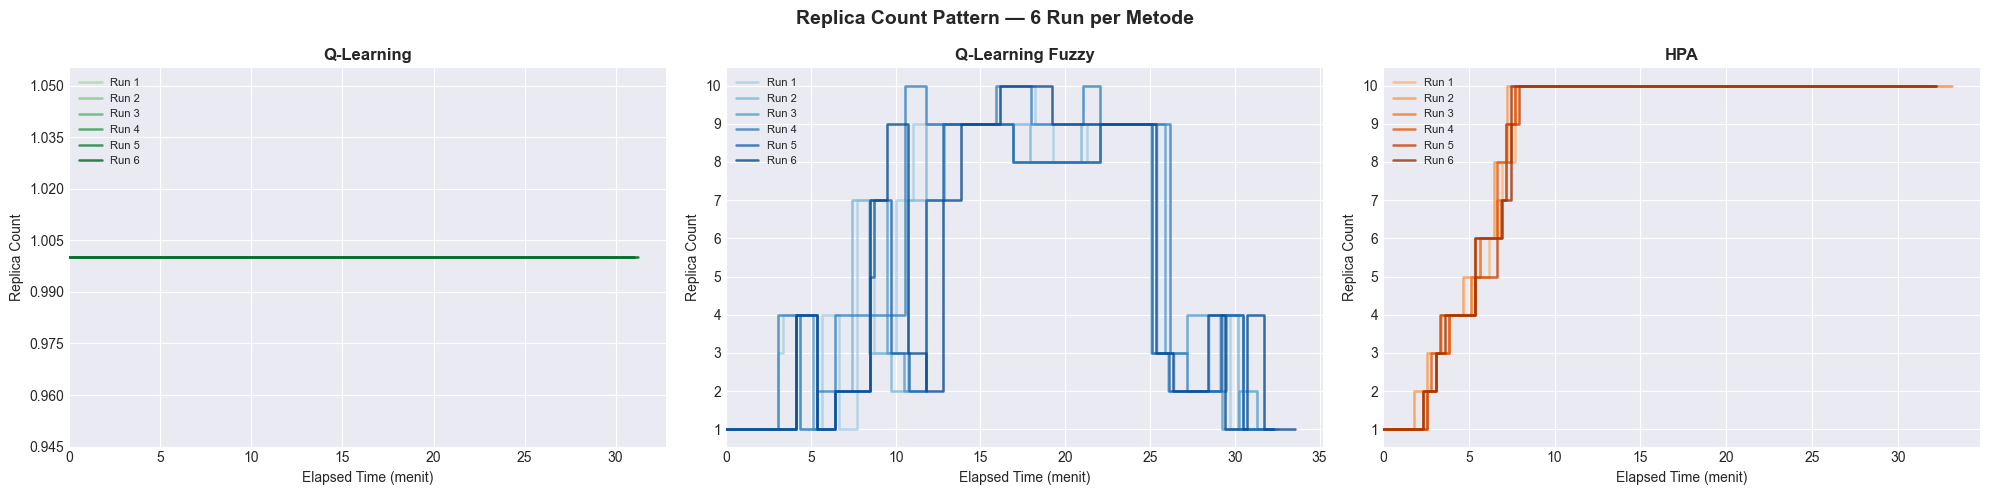

In [16]:
methods = list(DATASETS.keys())

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
fig.suptitle('Replica Count Pattern — 6 Run per Metode', fontsize=14, fontweight='bold')

for ax, method in zip(axes, methods):
    colors = METHOD_COLORS[method]
    dfs = ALL_DATA[method]

    for i, df in enumerate(dfs):
        ax.step(df['elapsed_min'], df['replica_state'], where='post',
                linewidth=1.8, alpha=0.8, color=colors[i], label=f'Run {i+1}')

    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('Elapsed Time (menit)')
    ax.set_ylabel('Replica Count')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 4. Pattern Replica Count — Mean ± Std Band

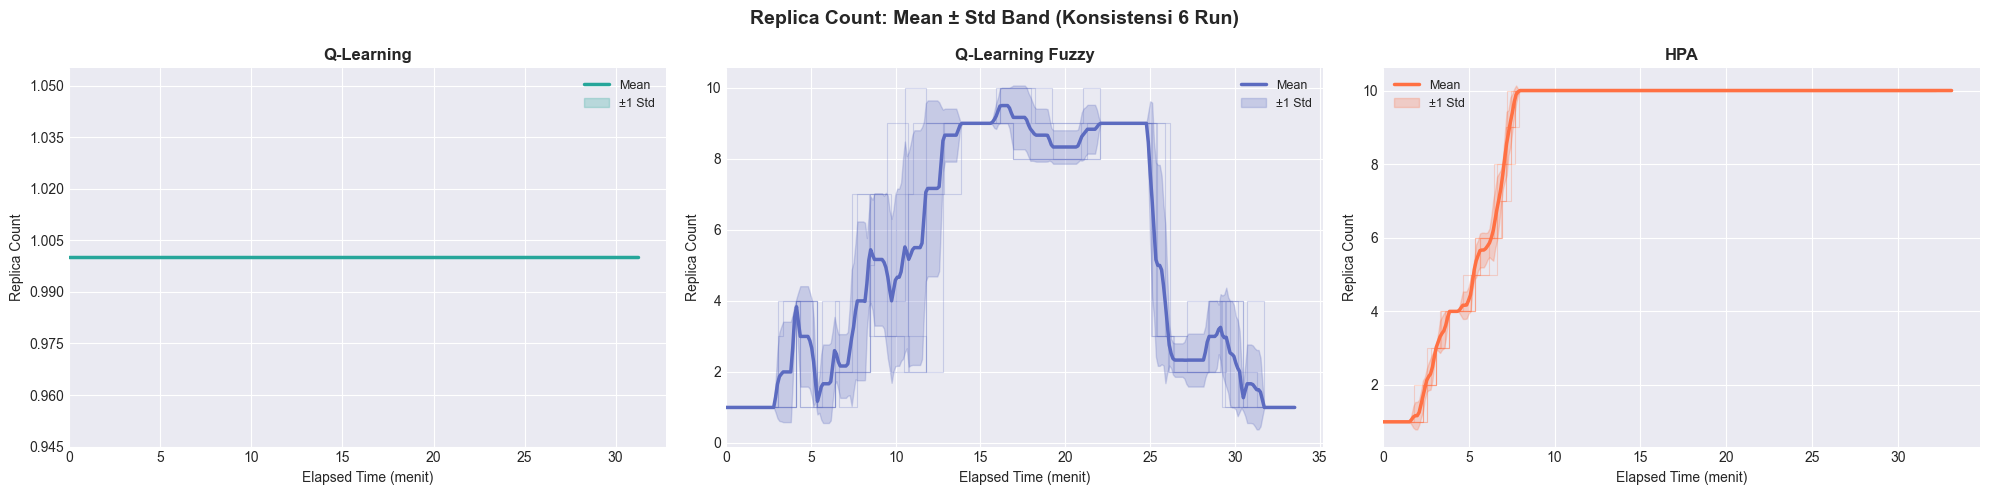

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
fig.suptitle('Replica Count: Mean ± Std Band (Konsistensi 6 Run)', fontsize=14, fontweight='bold')

for ax, method in zip(axes, methods):
    dfs = ALL_DATA[method]
    base_color = METHOD_BASE_COLOR[method]

    # Buat grid waktu seragam
    max_duration = max(df['elapsed_min'].iloc[-1] for df in dfs)
    t_grid = np.linspace(0, max_duration, 300)

    # Interpolasi setiap run ke grid waktu
    interp_matrix = []
    for df in dfs:
        interp_vals = np.interp(t_grid, df['elapsed_min'], df['replica_state'])
        interp_matrix.append(interp_vals)
    interp_matrix = np.array(interp_matrix)

    mean_vals = interp_matrix.mean(axis=0)
    std_vals  = interp_matrix.std(axis=0)

    # Plot individual runs (tipis & transparan)
    for i, df in enumerate(dfs):
        ax.step(df['elapsed_min'], df['replica_state'], where='post',
                linewidth=0.8, alpha=0.25, color=base_color)

    # Plot mean
    ax.plot(t_grid, mean_vals, linewidth=2.5, color=base_color, label='Mean')
    # Std band
    ax.fill_between(t_grid, mean_vals - std_vals, mean_vals + std_vals,
                    alpha=0.25, color=base_color, label='±1 Std')

    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('Elapsed Time (menit)')
    ax.set_ylabel('Replica Count')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=9)
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 5. Pattern SLO (Response Time)

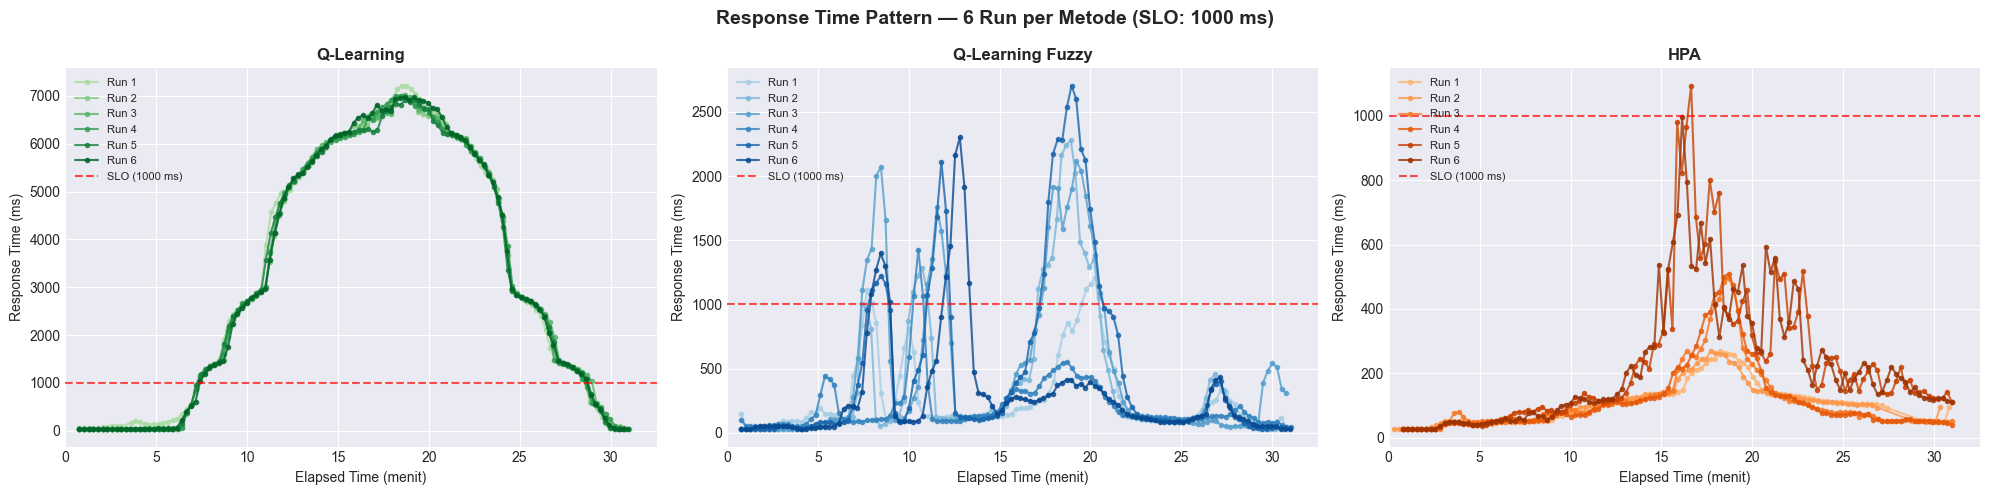

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
fig.suptitle(f'Response Time Pattern — 6 Run per Metode (SLO: {SLO_THRESHOLD} ms)', fontsize=14, fontweight='bold')

for ax, method in zip(axes, methods):
    colors = METHOD_COLORS[method]
    dfs = ALL_DATA[method]

    for i, df in enumerate(dfs):
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        if mask.sum() == 0:
            continue
        ax.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
                marker='o', markersize=3, linewidth=1.5,
                alpha=0.8, color=colors[i], label=f'Run {i+1}')

    ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--',
               linewidth=1.5, alpha=0.7, label=f'SLO ({SLO_THRESHOLD} ms)')
    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('Elapsed Time (menit)')
    ax.set_ylabel('Response Time (ms)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 6. Pattern SLO (Response Time) — Mean ± Std Band

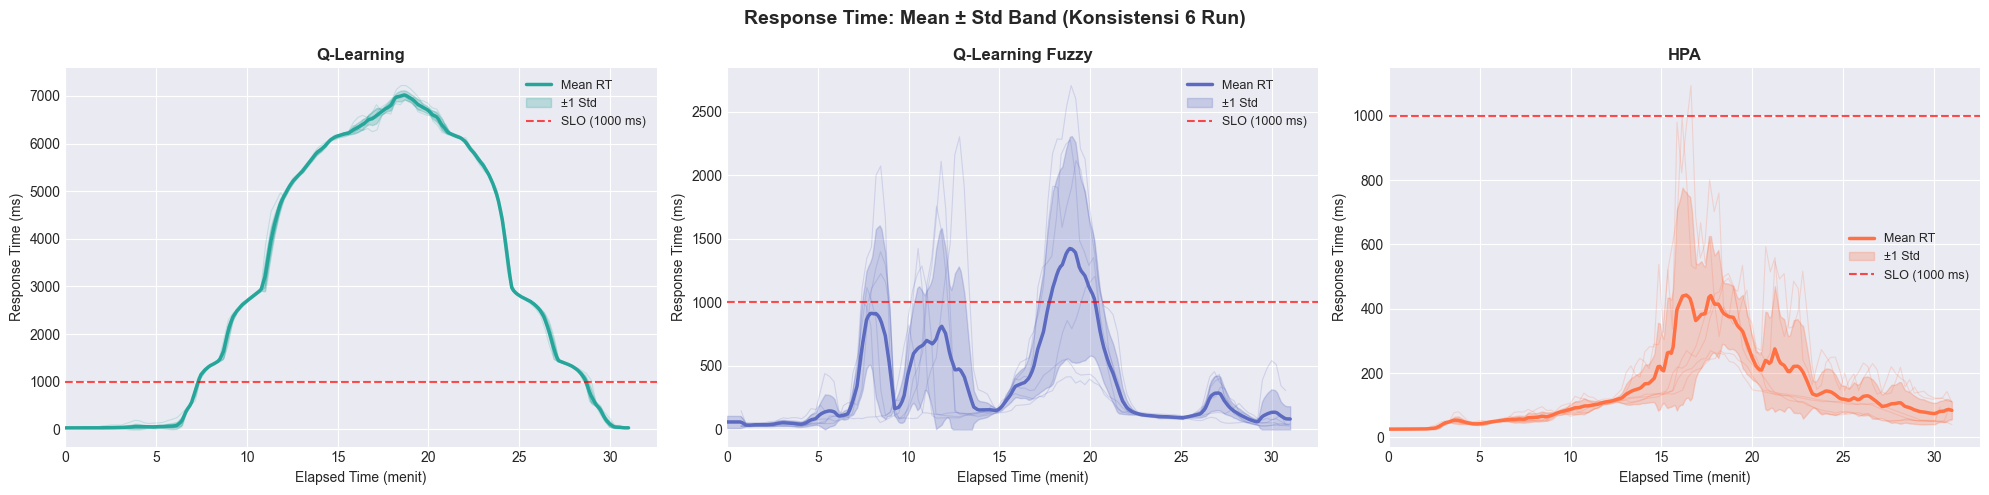

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
fig.suptitle('Response Time: Mean ± Std Band (Konsistensi 6 Run)', fontsize=14, fontweight='bold')

for ax, method in zip(axes, methods):
    dfs = ALL_DATA[method]
    base_color = METHOD_BASE_COLOR[method]

    # Kumpulkan semua data RT yang valid
    valid_dfs = []
    for df in dfs:
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        if mask.sum() > 0:
            valid_dfs.append(df[mask][['elapsed_min', 'response_time_ms']].copy())

    if valid_dfs:
        max_t = max(d['elapsed_min'].iloc[-1] for d in valid_dfs)
        t_grid = np.linspace(0, max_t, 300)

        interp_matrix = []
        for d in valid_dfs:
            interp_vals = np.interp(t_grid, d['elapsed_min'], d['response_time_ms'])
            interp_matrix.append(interp_vals)
        interp_matrix = np.array(interp_matrix)

        mean_rt = interp_matrix.mean(axis=0)
        std_rt  = interp_matrix.std(axis=0)

        # Individual runs (transparan)
        for d in valid_dfs:
            ax.plot(d['elapsed_min'], d['response_time_ms'],
                    linewidth=0.8, alpha=0.2, color=base_color)

        ax.plot(t_grid, mean_rt, linewidth=2.5, color=base_color, label='Mean RT')
        ax.fill_between(t_grid, np.maximum(0, mean_rt - std_rt), mean_rt + std_rt,
                        alpha=0.25, color=base_color, label='±1 Std')

    ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--',
               linewidth=1.5, alpha=0.7, label=f'SLO ({SLO_THRESHOLD} ms)')
    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('Elapsed Time (menit)')
    ax.set_ylabel('Response Time (ms)')
    ax.legend(fontsize=9)
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 7. Grid Pattern: Replica & SLO

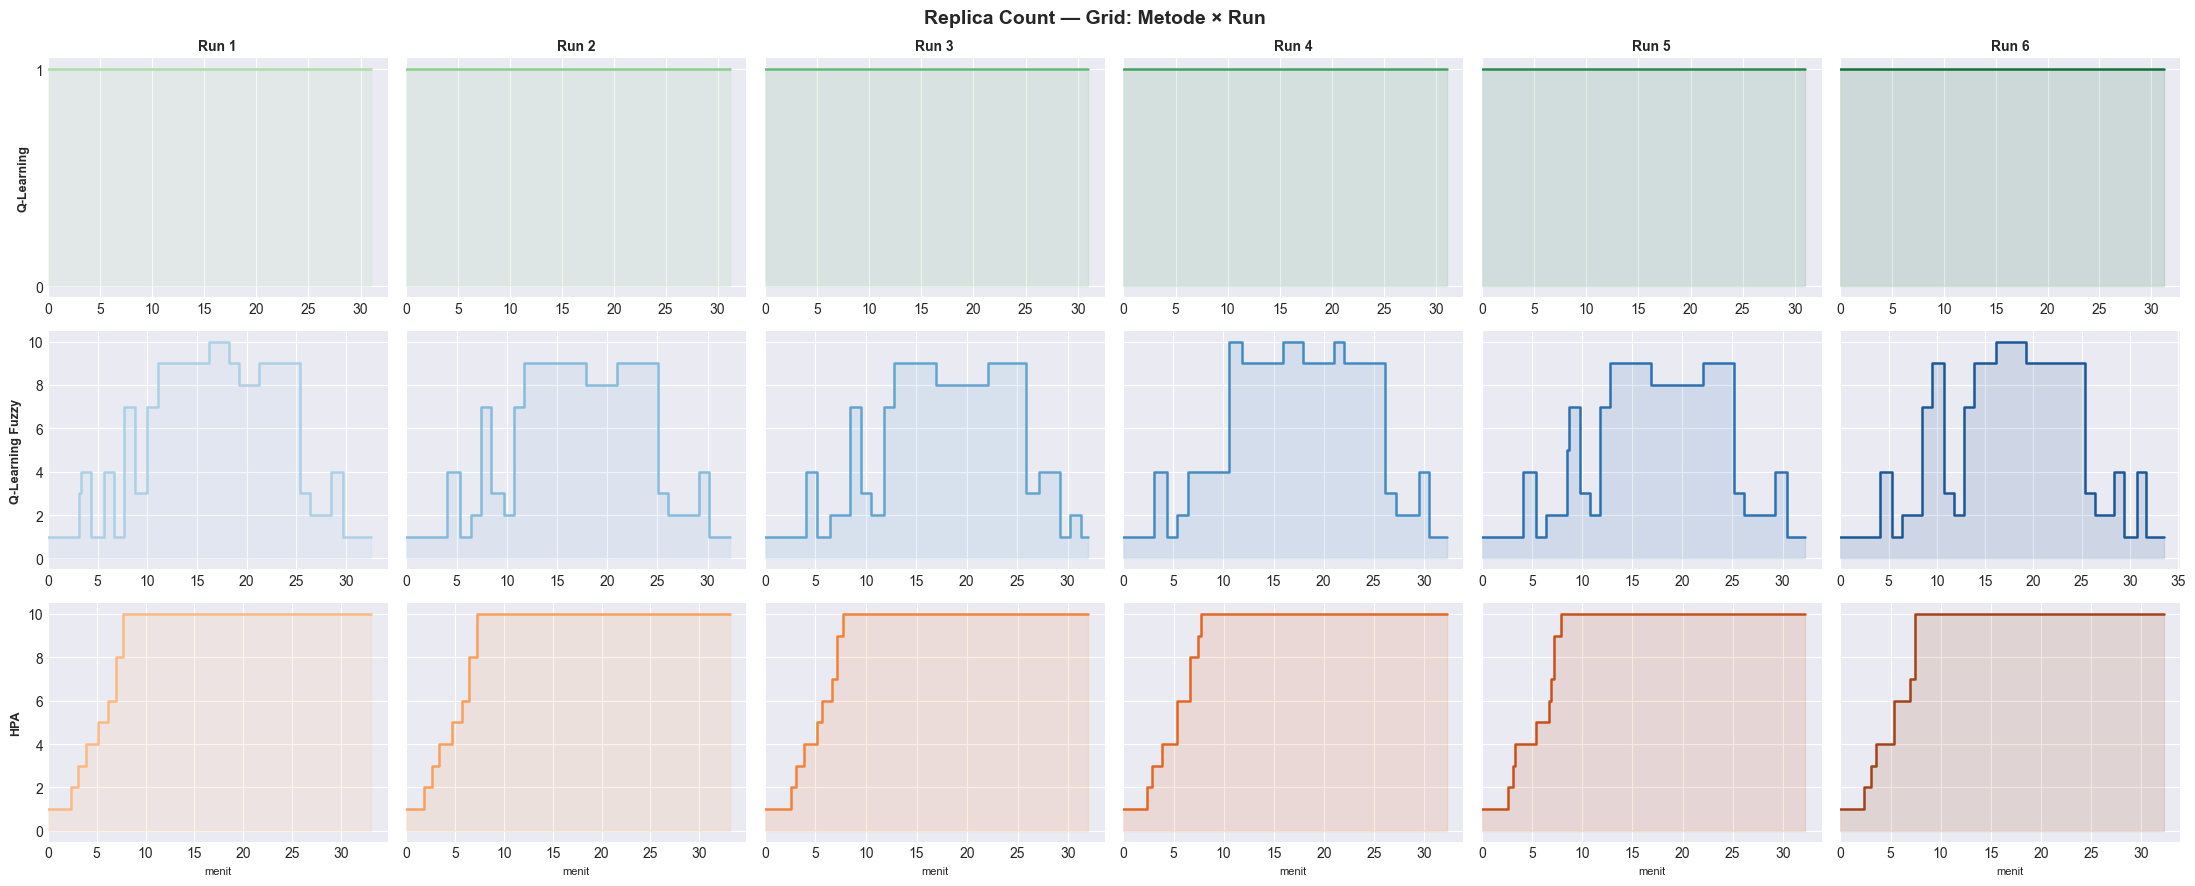

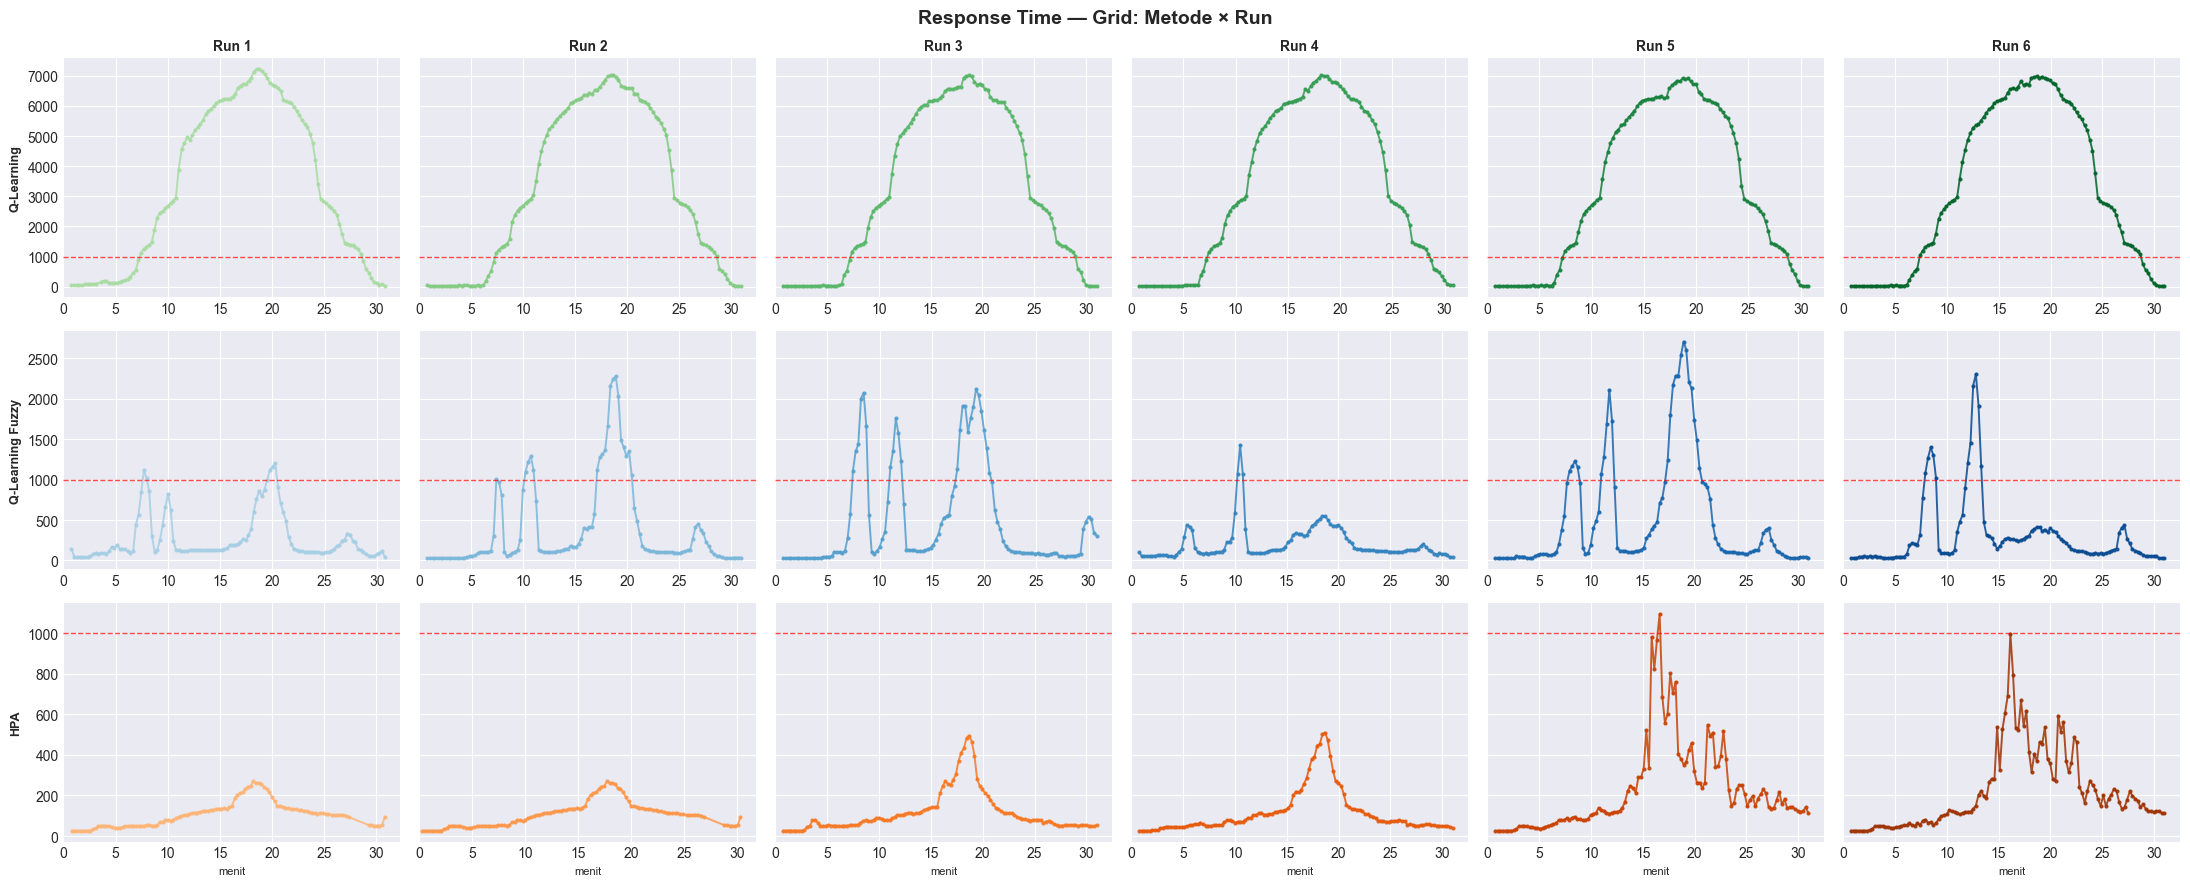

In [20]:
N_RUNS = 6

# ── Replica Count Grid ──────────────────────────────────────────
fig, axes = plt.subplots(3, N_RUNS, figsize=(22, 9), sharey='row')
fig.suptitle('Replica Count — Grid: Metode × Run', fontsize=14, fontweight='bold')

for row, method in enumerate(methods):
    colors = METHOD_COLORS[method]
    dfs = ALL_DATA[method]
    for col in range(N_RUNS):
        ax = axes[row, col]
        df = dfs[col] if col < len(dfs) else None
        if df is not None:
            ax.step(df['elapsed_min'], df['replica_state'], where='post',
                    linewidth=1.8, color=colors[col], alpha=0.9)
            ax.fill_between(df['elapsed_min'], 0, df['replica_state'],
                            step='post', alpha=0.12, color=colors[col])
            ax.set_xlim(left=0)
            ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        if row == 0:
            ax.set_title(f'Run {col+1}', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(method, fontsize=9, fontweight='bold')
        if row == 2:
            ax.set_xlabel('menit', fontsize=8)

plt.tight_layout()
plt.show()

# ── Response Time Grid ───────────────────────────────────────────
fig, axes = plt.subplots(3, N_RUNS, figsize=(22, 9), sharey='row')
fig.suptitle('Response Time — Grid: Metode × Run', fontsize=14, fontweight='bold')

for row, method in enumerate(methods):
    colors = METHOD_COLORS[method]
    dfs = ALL_DATA[method]
    for col in range(N_RUNS):
        ax = axes[row, col]
        df = dfs[col] if col < len(dfs) else None
        if df is not None:
            mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
            if mask.sum() > 0:
                ax.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
                        marker='o', markersize=2, linewidth=1.4,
                        color=colors[col], alpha=0.85)
            ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--',
                       linewidth=1.0, alpha=0.7)
            ax.set_xlim(left=0)
        if row == 0:
            ax.set_title(f'Run {col+1}', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(method, fontsize=9, fontweight='bold')
        if row == 2:
            ax.set_xlabel('menit', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Comparison Method — Mean Pattern

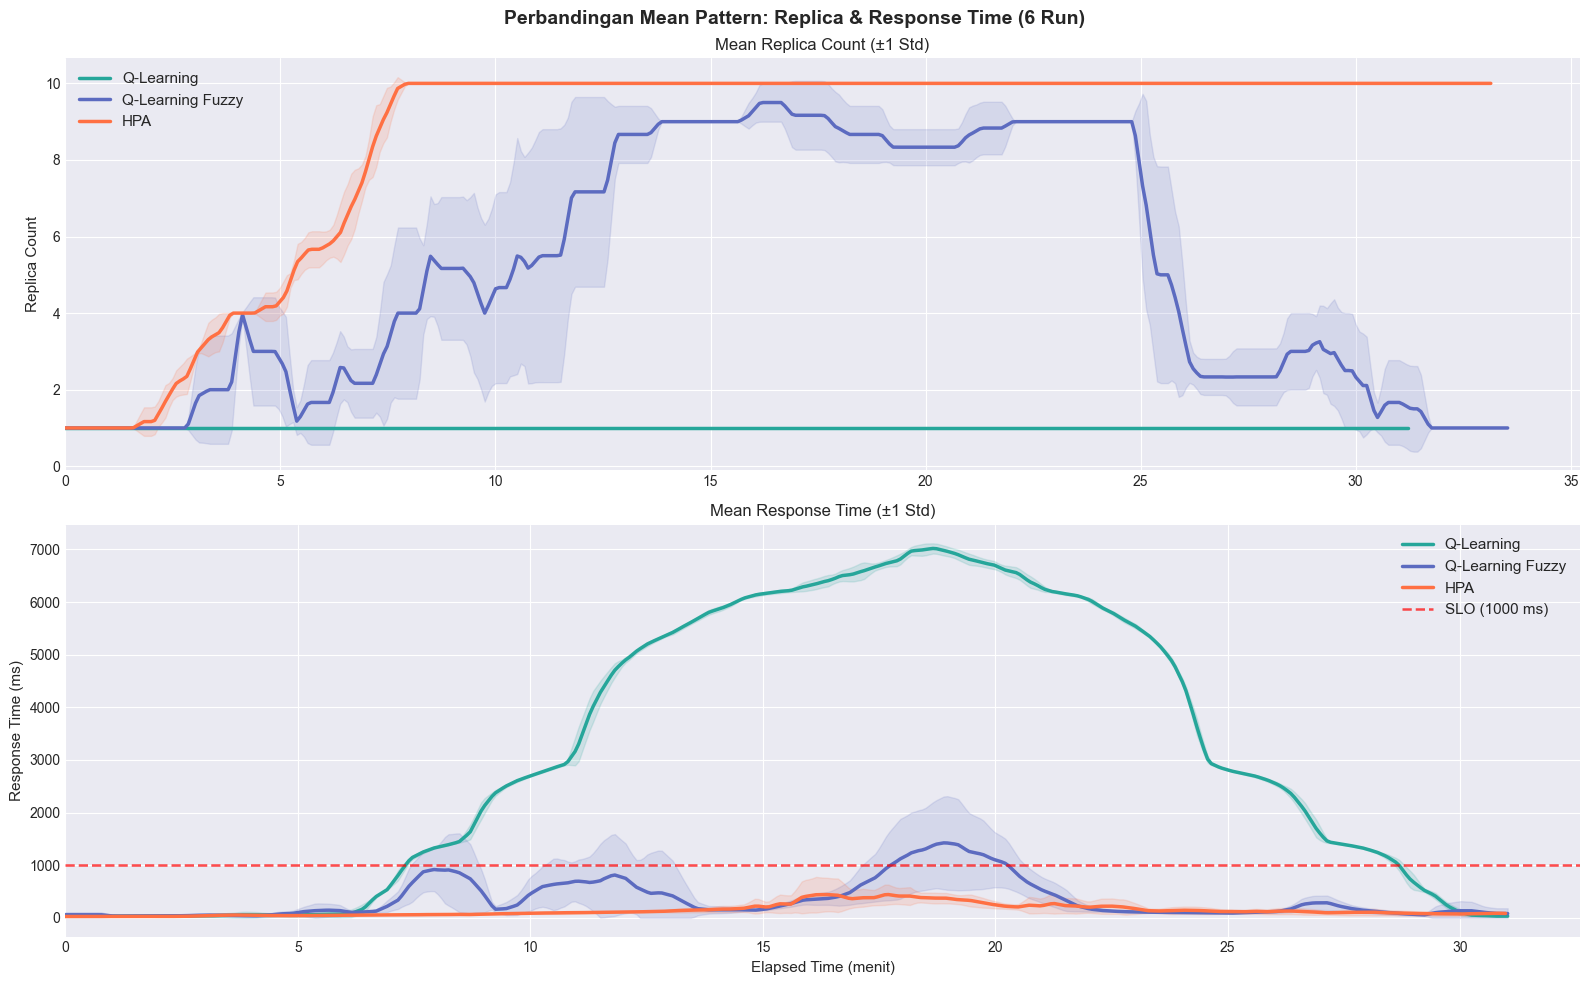

In [21]:
fig, (ax_rep, ax_rt) = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Perbandingan Mean Pattern: Replica & Response Time (6 Run)', fontsize=14, fontweight='bold')

for method in methods:
    dfs = ALL_DATA[method]
    base_color = METHOD_BASE_COLOR[method]

    # ── Replica ──────────────────────────────────────────────────
    max_t = max(df['elapsed_min'].iloc[-1] for df in dfs)
    t_grid = np.linspace(0, max_t, 400)
    rep_matrix = np.array([
        np.interp(t_grid, df['elapsed_min'], df['replica_state'])
        for df in dfs
    ])
    mean_rep = rep_matrix.mean(axis=0)
    std_rep  = rep_matrix.std(axis=0)

    ax_rep.plot(t_grid, mean_rep, linewidth=2.5, color=base_color, label=method)
    ax_rep.fill_between(t_grid, mean_rep - std_rep, mean_rep + std_rep,
                        alpha=0.15, color=base_color)

    # ── Response Time ─────────────────────────────────────────────
    valid_dfs = []
    for df in dfs:
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        if mask.sum() > 0:
            valid_dfs.append(df[mask][['elapsed_min', 'response_time_ms']].copy())

    if valid_dfs:
        max_t_rt = max(d['elapsed_min'].iloc[-1] for d in valid_dfs)
        t_grid_rt = np.linspace(0, max_t_rt, 400)
        rt_matrix = np.array([
            np.interp(t_grid_rt, d['elapsed_min'], d['response_time_ms'])
            for d in valid_dfs
        ])
        mean_rt = rt_matrix.mean(axis=0)
        std_rt  = rt_matrix.std(axis=0)

        ax_rt.plot(t_grid_rt, mean_rt, linewidth=2.5, color=base_color, label=method)
        ax_rt.fill_between(t_grid_rt, np.maximum(0, mean_rt - std_rt), mean_rt + std_rt,
                           alpha=0.15, color=base_color)

ax_rep.set_ylabel('Replica Count', fontsize=11)
ax_rep.set_title('Mean Replica Count (±1 Std)', fontsize=12)
ax_rep.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax_rep.legend(fontsize=11)
ax_rep.set_xlim(left=0)

ax_rt.axhline(y=SLO_THRESHOLD, color='red', linestyle='--',
              linewidth=1.8, alpha=0.7, label=f'SLO ({SLO_THRESHOLD} ms)')
ax_rt.set_ylabel('Response Time (ms)', fontsize=11)
ax_rt.set_xlabel('Elapsed Time (menit)', fontsize=11)
ax_rt.set_title('Mean Response Time (±1 Std)', fontsize=12)
ax_rt.legend(fontsize=11)
ax_rt.set_xlim(left=0)

plt.tight_layout()
plt.show()

## 9. Summary Statistics Method

In [22]:
records = []

for method, dfs in ALL_DATA.items():
    for i, df in enumerate(dfs):
        rt = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms']
        rep = df['replica_state']
        n_total = len(rt)
        n_viol  = (rt > SLO_THRESHOLD).sum() if n_total > 0 else 0
        records.append({
            'Method': method,
            'Run': i + 1,
            'Duration (s)': df['elapsed_s'].iloc[-1],
            'Replica Mean': rep.mean(),
            'Replica Min':  rep.min(),
            'Replica Max':  rep.max(),
            'RT Mean (ms)': rt.mean() if n_total > 0 else float('nan'),
            'RT Median':    rt.median() if n_total > 0 else float('nan'),
            'RT Max (ms)':  rt.max() if n_total > 0 else float('nan'),
            'SLO Violations': n_viol,
            'SLO Total':      n_total,
            'Violation %':    n_viol / n_total * 100 if n_total > 0 else float('nan'),
        })

summary_df = pd.DataFrame(records)

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(summary_df.to_string(index=False))

          Method  Run  Duration (s)  Replica Mean  Replica Min  Replica Max  RT Mean (ms)  RT Median  RT Max (ms)  SLO Violations  SLO Total  Violation %
      Q-Learning    1       1862.34          1.00            1            1       3281.65    2762.52      7217.90              83        117        70.94
      Q-Learning    2       1871.09          1.00            1            1       3193.22    2736.97      7023.40              84        119        70.59
      Q-Learning    3       1861.59          1.00            1            1       3198.94    2748.77      7019.62              85        119        71.43
      Q-Learning    4       1861.20          1.00            1            1       3214.82    2758.69      7009.09              83        118        70.34
      Q-Learning    5       1859.90          1.00            1            1       3215.92    2761.40      6917.22              84        118        71.19
      Q-Learning    6       1873.21          1.00            1            1 

In [23]:
# Agregasi per metode (rata-rata dari 6 run)
agg_cols = ['Replica Mean', 'Replica Min', 'Replica Max',
            'RT Mean (ms)', 'RT Median', 'RT Max (ms)',
            'SLO Violations', 'Violation %']

agg_df = summary_df.groupby('Method')[agg_cols].agg(['mean', 'std']).round(2)
agg_df.columns = [f'{c[0]} ({c[1]})' for c in agg_df.columns]

print('\n=== Agregasi per Metode (Mean ± Std dari 6 Run) ===')
print(agg_df.to_string())


=== Agregasi per Metode (Mean ± Std dari 6 Run) ===
                  Replica Mean (mean)  Replica Mean (std)  Replica Min (mean)  Replica Min (std)  Replica Max (mean)  Replica Max (std)  RT Mean (ms) (mean)  RT Mean (ms) (std)  RT Median (mean)  RT Median (std)  RT Max (ms) (mean)  RT Max (ms) (std)  SLO Violations (mean)  SLO Violations (std)  Violation % (mean)  Violation % (std)
Method                                                                                                                                                                                                                                                                                                                                        
HPA                              8.49                0.05                1.00               0.00               10.00               0.00               147.78               57.73            108.45            31.51              605.96             357.29                   0.17    

## 10. Boxplot Distribution: Replica & SLO

C:\Users\indra\AppData\Local\Temp\ipykernel_28464\3414411491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(rep_data, labels=bp_labels, patch_artist=True,
C:\Users\indra\AppData\Local\Temp\ipykernel_28464\3414411491.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(rt_data, labels=bp_labels, patch_artist=True,


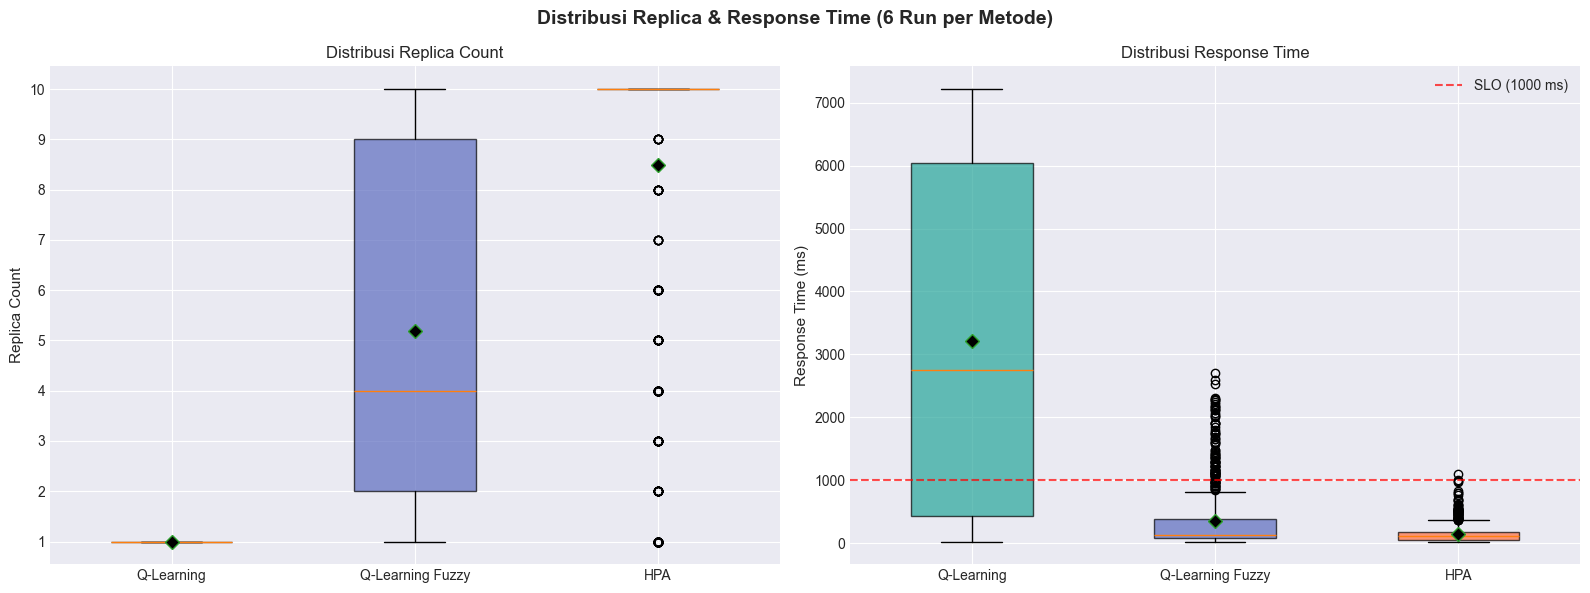

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribusi Replica & Response Time (6 Run per Metode)', fontsize=14, fontweight='bold')

bp_labels = methods
bp_colors = [METHOD_BASE_COLOR[m] for m in methods]

# ── Replica Count Boxplot ───────────────────────────────────────
ax = axes[0]
rep_data = [
    pd.concat([df['replica_state'] for df in ALL_DATA[m]]).values
    for m in methods
]
bp = ax.boxplot(rep_data, labels=bp_labels, patch_artist=True,
                widths=0.5, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 7})
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Replica Count', fontsize=11)
ax.set_title('Distribusi Replica Count', fontsize=12)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# ── Response Time Boxplot ────────────────────────────────────────
ax = axes[1]
rt_data = []
for m in methods:
    all_rt = []
    for df in ALL_DATA[m]:
        mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
        all_rt.extend(df.loc[mask, 'response_time_ms'].tolist())
    rt_data.append(np.array(all_rt))

bp = ax.boxplot(rt_data, labels=bp_labels, patch_artist=True,
                widths=0.5, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 7})
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--',
           linewidth=1.5, alpha=0.7, label=f'SLO ({SLO_THRESHOLD} ms)')
ax.set_ylabel('Response Time (ms)', fontsize=11)
ax.set_title('Distribusi Response Time', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 11. SLO Violation Rate per Run (Heatmap)

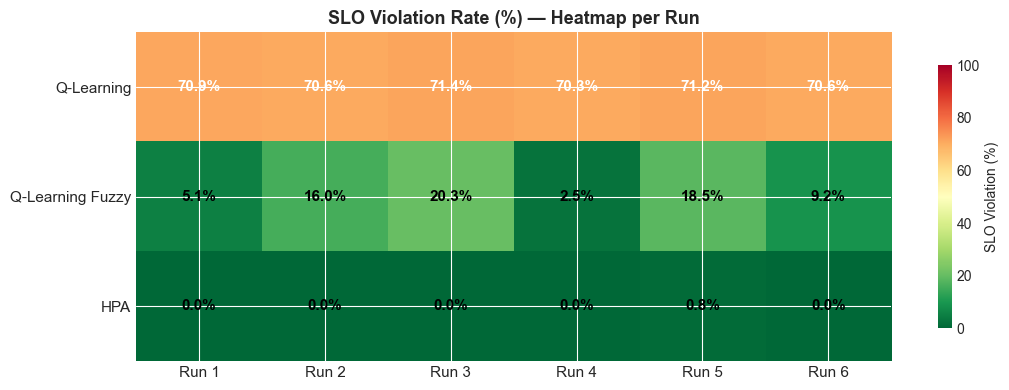

In [25]:
N_RUNS = 6

violation_matrix = np.full((len(methods), N_RUNS), np.nan)
for row, method in enumerate(methods):
    for col, df in enumerate(ALL_DATA[method]):
        rt = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms']
        if len(rt) > 0:
            violation_matrix[row, col] = (rt > SLO_THRESHOLD).sum() / len(rt) * 100

fig, ax = plt.subplots(figsize=(11, 4))

im = ax.imshow(violation_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='SLO Violation (%)', shrink=0.8)

ax.set_xticks(range(N_RUNS))
ax.set_xticklabels([f'Run {i+1}' for i in range(N_RUNS)], fontsize=11)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=11)
ax.set_title('SLO Violation Rate (%) — Heatmap per Run', fontsize=13, fontweight='bold')

# Annotate values
for row in range(len(methods)):
    for col in range(N_RUNS):
        val = violation_matrix[row, col]
        if not np.isnan(val):
            text_color = 'white' if val > 50 else 'black'
            ax.text(col, row, f'{val:.1f}%', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=text_color)

plt.tight_layout()
plt.show()